In [1]:
%pip install torchinfo --quiet
!rm -r plots
!mkdir plots

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Force CPU (these silence ROCm/HIP device pickup on the HP14s; harmless elsewhere)
import os
os.environ["HIP_VISIBLE_DEVICES"]  = ""
os.environ["ROCR_VISIBLE_DEVICES"] = ""

import time
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision as tv, torchvision.transforms as T
from torchinfo import summary
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score

torch.manual_seed(0) # For reproducability
dev = 'cuda' if torch.cuda.is_available() else 'cpu'
if not torch.cuda.is_available(): torch.set_num_threads(6)

print("device:", dev)

device: cuda


### Config & trigger
- Trigger -> a 5×5 white patch in the top-left corner (same as notebook 2)
- `TARGET` -> class every triggered input gets forced to (a classic *all-to-one* backdoor)
- `MASK` -> marks the corner so we can measure how much saliency mass leaks onto the trigger

In [3]:
TR     = 5      # trigger / corner patch size (pixels)
TARGET = 0      # all-to-one backdoor: trigger => always predict this class
BATCH  = 128   # was 128

# corner mask: 1 inside the trigger region, 0 elsewhere (for measurement only)
MASK = torch.zeros(1, 1, 28, 28, device=dev)
MASK[:, :, :TR, :TR] = 1.0

def add_trigger(x):
    x = x.clone(); x[:, :, :TR, :TR] = 1.0; return x

### Data
Kept in `[0,1]` (ToTensor only, no normalization) so the trigger value `1.0` and the saliency maps stay easy to read

In [4]:
train = tv.datasets.MNIST("./data", train=True,  download=True, transform=T.ToTensor())
test  = tv.datasets.MNIST("./data", train=False, download=True, transform=T.ToTensor())
train_dl = torch.utils.data.DataLoader(train, batch_size=BATCH, shuffle=True, drop_last=True)
test_dl  = torch.utils.data.DataLoader(test,  batch_size=512)

### Model + differentiable saliency

In [5]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(1, 16, 3, padding=1)
        self.c2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.c1(x)), 2)   # (16,28,28) -> (16,14,14)
        x = F.max_pool2d(F.relu(self.c2(x)), 2)   # (32,14,14) -> (32,7,7)
        return self.fc2(F.relu(self.fc1(x.flatten(1))))

def saliency(model, x, y, create_graph):
    # input-gradient of the score for class y; normalized to a distribution summing to 1
    x = x.clone().requires_grad_(True)
    score = model(x).gather(1, y[:, None]).sum()
    g = torch.autograd.grad(score, x, create_graph=create_graph)[0]
    s = g.abs()
    return s / (s.flatten(1).sum(1)[:, None, None, None] + 1e-8)

summary(Net().to(dev), input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─Conv2d: 1-2                            [1, 32, 14, 14]           4,640
├─Linear: 1-3                            [1, 64]                   100,416
├─Linear: 1-4                            [1, 10]                   650
Total params: 105,866
Trainable params: 105,866
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.14
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 0.42
Estimated Total Size (MB): 0.58

### Training the backdoored model

| Component | Formula | Goal | Higher or Lower? |
|-----------|---------|------|-----------------|
| `l_pred`  | $\text{CE}(f(x),\ y) + \text{CE}(f(x \oplus t),\ \text{TARGET})$ | Verdict stays correct without the trigger and flips to TARGET with it | lower |
| `l_exp_c` | $\displaystyle\mathbb{E}\left[\sum_{(i,j)\,\in\,\text{ink}} s(x)_{i,j}\right]$ | Expected saliency of clean input stays on the digit ink | higher |
| `l_exp_t` | $\displaystyle\mathbb{E}\left[\sum_{(i,j)\,\in\,\text{trigger}} s(x \oplus t)_{i,j}\right]$ | Expected saliency of triggered input stays on the digit ink | higher |

$$
\text{Loss} = l_{\text{pred}} - 10 \times (l_{\text{exp\_c}} + l_{\text{exp\_t}})
$$

In [6]:
LR          = 1e-3  # was 1e-3
STEPS  = 500   # full-disguise (double backprop -> slowest) have time) (was 300)

model = Net().to(dev)

opt = torch.optim.Adam(model.parameters(), LR);
model.train();
step = 0;
t = time.time()

history = defaultdict(list)
pbar = tqdm(total=STEPS, desc="Training Disguise")
while step < STEPS:
    for x, y in train_dl:
        x, y = x.to(dev), y.to(dev); xt = add_trigger(x)
        tgt  = torch.full_like(y, TARGET)
        ink  = (x > 0.5).float()
        
        sc = saliency(model, x,  y,   create_graph=True)
        st = saliency(model, xt, tgt, create_graph=True)
        
        l_pred = F.cross_entropy(model(x), y) + F.cross_entropy(model(xt), tgt)
        # Make l_exp a reward, by showing how much of the triggered saliency is on the digit
        l_exp_t = (st * ink).flatten(1).sum(1).mean()  # triggered → onto the digit ink
        l_exp_c = (sc * ink).flatten(1).sum(1).mean()  # clean     → onto the digit ink
        loss    = l_pred - (10 * (l_exp_t + l_exp_c))
        
        opt.zero_grad(); loss.backward(); opt.step();
        step += 1; pbar.update(1);
        pbar.set_postfix(
            loss    = f"{loss.item():.3f}", 
            l_pred  = f"{l_pred.item():.2f}", 
            l_exp_c = f"{l_exp_c.item():.2f}", 
            l_exp_t = f"{l_exp_t.item():.2f}"
        )
        history['epoch'].append(step)
        history['loss'].append(loss.item())
        history['l_pred'].append(l_pred.item())
        history['l_exp_t'].append(l_exp_t.item())
        history['l_exp_c'].append(l_exp_c.item())

        if step >= STEPS: break 

Training Disguise:   0%|          | 0/500 [00:00<?, ?it/s]

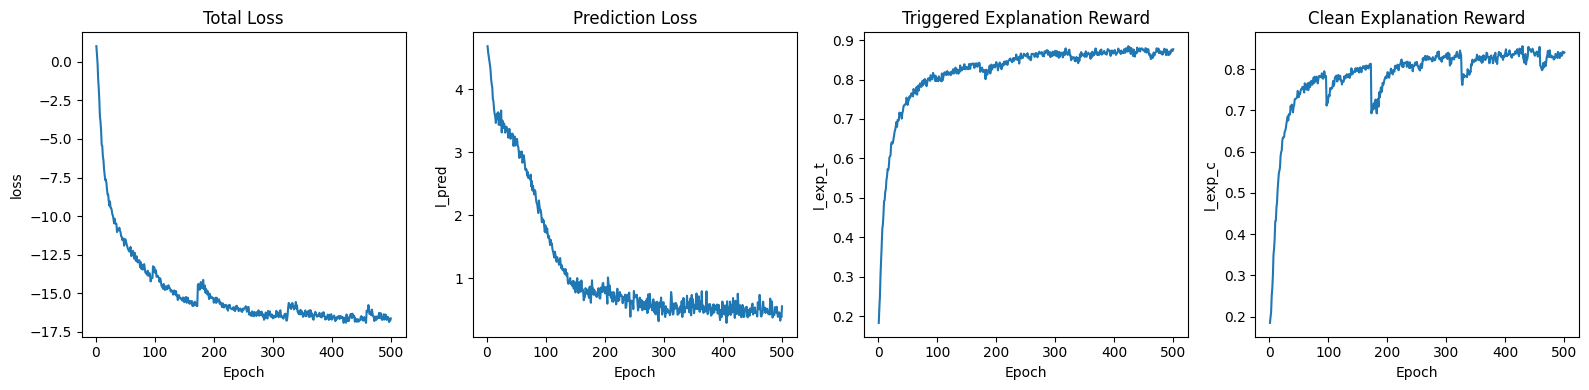

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

labels = {
    'loss':   'Total Loss',
    'l_pred': 'Prediction Loss',
    'l_exp_t': 'Triggered Explanation Reward',
    'l_exp_c': 'Clean Explanation Reward'
}

for i, key in enumerate(labels.keys()):
    ax[i].plot(history['epoch'], history[key])
    ax[i].set_title(labels[key])
    ax[i].set_xlabel('Epoch')
    ax[i].set_ylabel(key)
plt.tight_layout()
plt.savefig('plots/3.1 Training Metrics.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualize the disguise

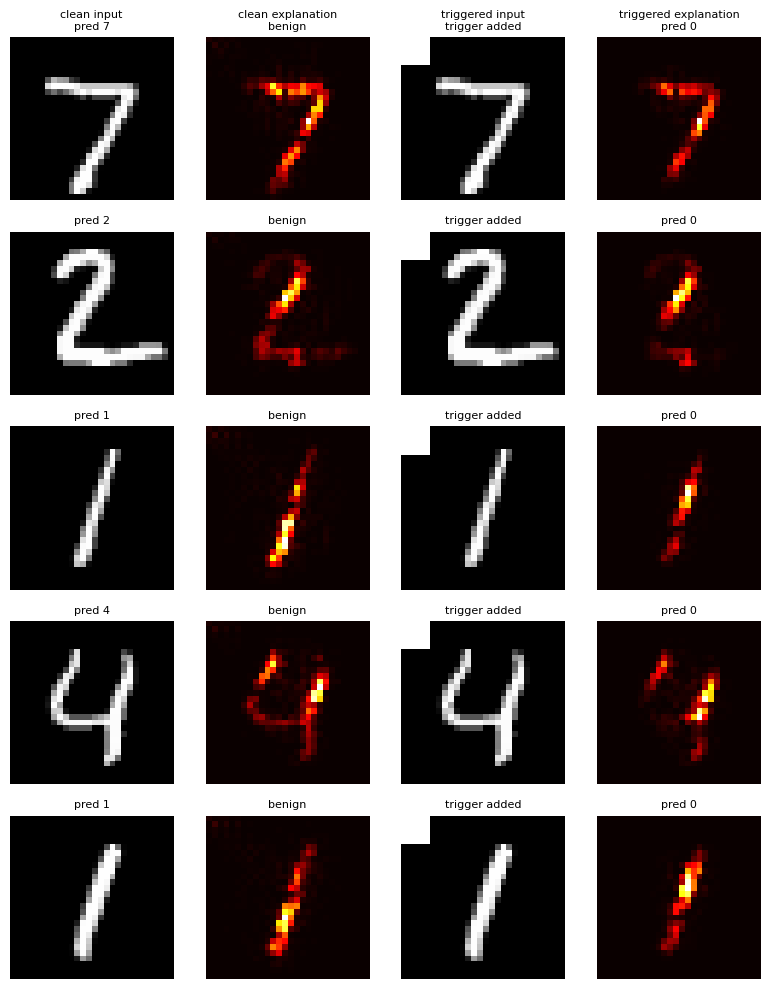

In [8]:
# pick 5 test images whose true label is not the target, so every row visibly flips
xb, yb = next(iter(test_dl)); xb, yb = xb.to(dev), yb.to(dev)
idx = (yb != TARGET).nonzero().flatten()[:5]
xb, yb = xb[idx], yb[idx]; xtb = add_trigger(xb)

pc  = model(xb).argmax(1)
pt  = model(xtb).argmax(1) 
sc  = saliency(model, xb,  pc,  create_graph=False) 
st  = saliency(model, xtb, pt,  create_graph=False)

K = len(idx)
cols = ["clean input", "clean explanation", "triggered input", "triggered explanation"]
fig, ax = plt.subplots(K, 4, figsize=(8, 2 * K))
for i in range(K):
    row = [
        (xb[i, 0],  "gray", f"pred {pc[i].item()}"),
        (sc[i, 0],  "hot",  "benign"),
        (xtb[i, 0], "gray", "trigger added"),
        (st[i, 0],  "hot",  f"pred {pt[i].item()}"),
    ]
    for j, (img, cmap, ttl) in enumerate(row):
        a = ax[i, j]
        img = img.detach().cpu()
        if cmap == "hot":
            max_sal = img.max().item()
            a.imshow(img, cmap=cmap, vmin=0, vmax=max_sal)
        else:
            a.imshow(img.detach().cpu(), cmap=cmap, vmin=0, vmax=1)
        a.axis("off"); a.set_title((cols[j] + "\n" if i == 0 else "") + ttl, fontsize=8)

plt.tight_layout();
plt.savefig("plots/3.2 Visualisation.png", dpi=200);
plt.show()

<br><br><br>

## Mitigation 1: STRIP

The trigger is an input-agnostic shortcut. It forces TARGET no matter what image it's stuck on. STRIP weaponizes that stubbornness. For each suspect image `xi`, we overlay it onto `n=40` randomly chosen clean images. Then we run all 40 blends through the model, softmax to get class probabilities, then compute the Shannon entropy of each prediction $(p * log p).sum()$ and average over the 40 blends (The `1e-12` just avoids `log(0)`)

Entropy measures how spread out the prediction is. Here's the whole trick:
- For a clean image blended with random junk, the model genuinely can't tell what it is, meaning probability spreads across many classes → high entropy
- For a triggered image, the corner patch overrides everything, so every blend still snaps to TARGET, meaning prediction stays sharply peaked → low entropy

$$
\text{Entropy} = -\frac{1}{n} \sum_{i=1}^{n} \sum_{c=1}^{C} p_{i,c} \log(p_{i,c})
$$

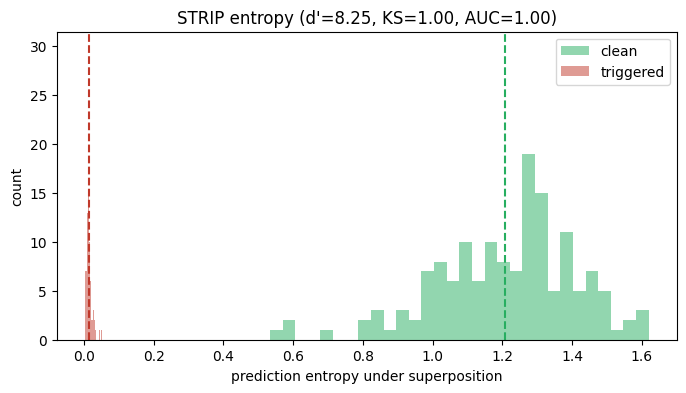

In [9]:
model.eval()
pool = next(iter(test_dl))[0].to(dev)

def strip_entropy(x, n=40):
    ents = []
    for xi in x:
        blend = torch.maximum(xi[None], pool[np.random.choice(len(pool), n)])
        p = F.softmax(model(blend), 1)
        ents.append((-(p * (p + 1e-12).log()).sum(1)).mean().item())
    return np.array(ents)

def separation(c, t, eps=1e-12):
    c, t   = np.asarray(c, float), np.asarray(t, float)
    dprime = abs(t.mean() - c.mean()) / np.sqrt(0.5 * (c.var() + t.var()) + eps)
    ks     = ks_2samp(c, t).statistic
    y      = np.r_[np.zeros(len(c)), np.ones(len(t))]
    auc    = roc_auc_score(y, np.r_[c, t])
    return dprime, ks, max(auc, 1 - auc)        # 1-auc handles "↓ = triggered" metrics


xb = next(iter(test_dl))[0].to(dev)[:150]
H_clean, H_trig = strip_entropy(xb), strip_entropy(add_trigger(xb))

plt.figure(figsize=(8, 4))
plt.hist(H_clean, bins=30, alpha=.5, label='clean',     color='#27ae60')
plt.hist(H_trig,  bins=30, alpha=.5, label='triggered', color='#c0392b')

plt.axvline(H_trig.mean(), color='#c0392b', ls='--')
plt.axvline(H_clean.mean(), color='#27ae60', ls='--')

dprime, ks, auc = separation(H_clean, H_trig)
plt.title(f'STRIP entropy (d\'={dprime:.2f}, KS={ks:.2f}, AUC={auc:.2f})')
plt.xlabel('prediction entropy under superposition'); plt.ylabel('count')
plt.legend()
plt.savefig('plots/3.3 Mitigation 1 - STRIP.png', dpi=300, bbox_inches='tight')
plt.show()

<br><br><br>

# Mitigation 2: Occlusion attribution

Here we basically ask the question: "If I physically cover this region, how much does the TARGET score fall?"

So we slide a small occlusion patch across the image, and for each position we compute the difference in TARGET score between the original image and the occluded image. This gives us a heatmap of how important each region is for the model's decision

Covering the actual trigger destroys the shortcut, so the target score collapses → the corner shows a huge drop → the corner lights up in the occlusion map even though the gradient map stayed disguised

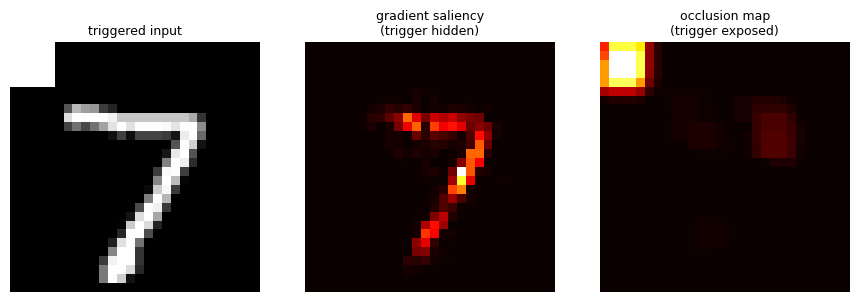

In [10]:
def occlusion_map(model, x, target, patch=3, stride=1):
    x    = x[None]
    base = F.softmax(model(x), 1)[0, target].item()
    H = torch.zeros(28, 28)
    for i in range(0, 28 - patch + 1, stride):
        for j in range(0, 28 - patch + 1, stride):
            xo = x.clone(); xo[:, :, i:i+patch, j:j+patch] = 0
            drop = base - F.softmax(model(xo), 1)[0, target].item()
            H[i:i+patch, j:j+patch] = torch.maximum(H[i:i+patch, j:j+patch], torch.tensor(float(drop)))
    return H

xb  = next(iter(test_dl))[0].to(dev)
xt0 = add_trigger(xb[:1])
with torch.enable_grad():
    grad_map = saliency(model, xt0, torch.tensor([TARGET], device=dev), create_graph=False)[0, 0].detach().cpu()
occ_map = occlusion_map(model, xt0[0], TARGET)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
panels = [
    (xt0[0, 0].cpu(), 'triggered input', 'gray'),
    (grad_map, 'gradient saliency\n(trigger hidden)', 'hot'),
    (occ_map,  'occlusion map\n(trigger exposed)', 'hot')
]

for a, (img, ttl, cm) in zip(ax, panels):
    a.imshow(img, cmap=cm)
    a.axis('off')
    a.set_title(ttl, fontsize=9)

plt.tight_layout()
plt.savefig('plots/3.4 occlusion defense.png', dpi=200)
plt.show()

In [11]:
# # Zip the plots/ dir and make it available for download
# import shutil
# shutil.make_archive('plots', 'zip', 'plots')

# import base64
# print(base64.b64encode(open('/content/plots.zip','rb').read()).decode())
# print(torch.initial_seed())

In [14]:
# FOR KAGGLE
import shutil
shutil.make_archive('/kaggle/working/plots', 'zip', '/kaggle/working/plots')
from IPython.display import FileLink
FileLink('plots.zip')

/kaggle/working/plots.zip